In [24]:
import os
!pip install langchain langchain_core langchain_community langgraph langchain_groq

In [25]:
import os
from typing import TypedDict,Annotated,List
from langgraph.graph import StateGraph,END
from langchain_core.messages import HumanMessage,AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display,Image

##Define Agent

In [26]:
class PlannerState(TypedDict):
  messages: Annotated[List[HumanMessage | AIMessage],"the Messages in the converastion"]
  city:str
  interests:List[str]
  itnerary: str

In [27]:
from langchain_groq import ChatGroq

llm=ChatGroq(
    temperature=0,
    groq_api_key="",
    model_name="llama-3.3-70b-versatile"
)

result=llm.invoke("what is Multi AI Agent?")
result

AIMessage(content='A Multi-Agent System (MAS) is a system composed of multiple autonomous agents that interact with each other and their environment to achieve common or individual goals. In the context of Artificial Intelligence (AI), a Multi-AI Agent refers to a system that consists of multiple AI agents that work together to solve complex problems, make decisions, or perform tasks.\n\nCharacteristics of Multi-AI Agents:\n\n1. **Autonomy**: Each AI agent has its own autonomy to make decisions and take actions.\n2. **Interactions**: AI agents interact with each other, sharing information, coordinating actions, and negotiating goals.\n3. **Distributed Problem-Solving**: Multiple AI agents work together to solve complex problems that are difficult or impossible for a single agent to solve.\n4. **Decentralized Decision-Making**: Decision-making is distributed among the AI agents, allowing for more flexible and adaptive problem-solving.\n\nTypes of Multi-AI Agents:\n\n1. **Cooperative Age

In [28]:
itinerary_prompt=ChatPromptTemplate.from_messages([
    ("system", "You are a helpful travel assisant. Create a day trip itinerary for {city} based on the user's interests:{interests}. provide a brief, bulleted itinerary"),
    ("human", "Create an itinerary for my day trip."),

])

##Define agent Functin

In [29]:
def input_city(state: PlannerState) -> PlannerState:
  print("please enter the city you want to visit for your day trip: ")
  user_message = input("Your Input: ")
  return {
      **state,
      "city": user_message,
      "messages": state['messages'] + [HumanMessage(content=user_message)]
  }

def input_interest(state: PlannerState) -> PlannerState:
  print(f"please enter your interest for the trip to : {state['city']} (comma-separted): ")
  user_message = input("Your Input: ")
  return {
      **state,
      "interests": [interest.strip() for interest in user_message.split(",")],
      "messages": state['messages'] + [HumanMessage(content=user_message)]
  }

def create_itinerary(state: PlannerState) -> PlannerState:
  print(f"Creating an itinerary for {state['city']} based on interests : {', '.join(state['interests'])}")
  response=llm.invoke(itinerary_prompt.format_messages(city=state['city'], interests = ','.join(state['interests'])))
  print("\nFinal Itinerary: ")
  print(response.content)
  return {
      **state,
      "messages": state['messages'] + [AIMessage(content=response.content)],
      "itinerary" : response.content
  }

##Create and Compile the Graph

In [30]:
workflow=StateGraph(PlannerState)

workflow.add_node("input_city",input_city)
workflow.add_node("input_interest",input_interest)
workflow.add_node("create_itinerary",create_itinerary)

workflow.set_entry_point("input_city")

workflow.add_edge("input_city","input_interest")
workflow.add_edge("input_interest","create_itinerary")
workflow.add_edge("create_itinerary",END)

app=workflow.compile()

##Display the graph structure

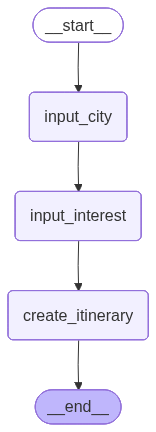

In [31]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method = MermaidDrawMethod.API
        )
    )
)

##Define the function thats runs the graph

In [32]:
def travel_planner(user_request: str):
  print(f"Initial Request: {user_request}\n")
  state = {
      "messages": [HumanMessage(content=user_request)],
      "city": "",
      "interests": [],
      "itinerary": "",
  }
  for output in app.stream(state):
    pass

In [33]:
user_request = "I want to plan a day trip"
travel_planner(user_request)

Initial Request: I want to plan a day trip

please enter the city you want to visit for your day trip: 
Your Input: mekka
please enter your interest for the trip to : mekka (comma-separted): 
Your Input: prayr, reading, zkr
Creating an itinerary for mekka based on interests : prayr, reading, zkr

Final Itinerary: 
For a day trip to Mecca, based on your interests in prayer, reading, and remembrance (Zkr), here's a brief itinerary:

* 6:00 AM: Fajr prayer at the Masjid al-Haram (Grand Mosque)
* 8:00 AM: Visit the Holy Quran Exhibition to explore Islamic scriptures and manuscripts
* 10:00 AM: Perform Tawaf (circumambulation) around the Kaaba and make supplications
* 12:00 PM: Attend a lecture or workshop on Islamic studies and Zkr at a local Islamic center
* 2:00 PM: Visit the Cave of Hira, where the Prophet Muhammad (peace be upon him) received his first revelation
* 4:00 PM: Asr prayer at the Masjid al-Haram, followed by quiet reflection and remembrance (Zkr)
* 6:00 PM: Maghrib prayer a

In [34]:
!pip install gradio

In [39]:
import gradio as gr
from typing import TypedDict,Annotated,List
from langgraph.graph import StateGraph,END
from langchain_core.messages import HumanMessage,AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from langchain_groq import ChatGroq

class PlannerState(TypedDict):
  messages: Annotated[List[HumanMessage | AIMessage],"the Messages in the converastion"]
  city:str
  interests:List[str]
  itnerary: str

  #Define the LLM
  llm=ChatGroq(
    temperature=0,
    groq_api_key="",
    model_name="llama-3.3-70b-versatile"
)

#Define the itinerary prompt
itinerary_prompt=ChatPromptTemplate.from_messages([
    ("system", "You are a helpful travel assisant. Create a day trip itinerary for {city} based on the user's interests:{interests}. provide a brief, bulleted itinerary"),
    ("human", "Create an itinerary for my day trip."),

])

def input_city(city: str, state: PlannerState) -> PlannerState:
  return {
      **state,
      "city": city,
      "messages": state['messages'] + [HumanMessage(content=city)],
  }

def input_interests(interests: str,state: PlannerState) -> PlannerState:
  return {
      **state,
      "interests": [interest.strip() for interest in interests.split(',')],
      "messages": state['messages'] + [HumanMessage(content=interests)],
  }

def create_itinerary(state: PlannerState) -> str:
  response=llm.invoke(itinerary_prompt.format_messages(city=state['city'], interests = ','.join(state['interests'])))
  state["itinerary"]=response.content
  state["messages"] += [AIMessage(content=response.content)]
  return response.content

  #Define the gradio application
  def travel_planner(city: str, interests: str):
    state = {
        "messages": [],
        "city": "",
        "interests": [],
        "itinerary": "",
  }

#process the city

  state = input_city(city, state)
  state= input_interests(interests, state)

  #Generate the itinerary

  itinerary=create_itinerary(state)

  return itineraray

#Build the gradio

interface=gr.Interface(
    fn=travel_planner,
    theme='Yntec/HalryCH_Theme_Orange_Green',
    inputs=[
        gr.Textbox(label="Enter the city for your day trip"),
        gr.Textbox(label="Enter the interests for your interests(comma-separated)"),

    ],
    outputs=gr.Textbox(label="Generated Itinerary"),
    title="Traavel Itinerary Planner",
    description="Enter a city and your interests to generate a personalized day trip itinerary"
)

interface.launch()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/gradio/blocks.py:1143: UserWarning: Cannot load Yntec/HalryCH_Theme_Orange_Green. Caught Exception: The space Yntec/HalryCH_Theme_Orange_Green does not exist
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")
/usr/local/lib/python3.12/dist-packages/gradio/utils.py:1052: UserWarning: Expected 1 arguments for function <function travel_planner at 0x7b7c3d307380>, received 2.
  warnings.warn(
/usr/local/lib/python3.12/dist-pa

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4e1bd7e9e7b31e1415.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
